In [14]:
# Load packages and basic plot settings
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib import pyplot
import seaborn as sns
import numpy as np
import pandas as pd
from matplotlib.colors import to_hex
from plotly.subplots import make_subplots
import plotly
import json
import plotly.graph_objects as go
from os import walk

from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from mutexa.rollingAvePlots import initialization

pyplot.rcParams['figure.dpi'] = 600
pyplot.rcParams['savefig.dpi'] = 600


In [15]:
def initialization(csvfile):
    countryGrouping = pd.read_csv(csvfile)
    countryGrouping = countryGrouping[['Sub-region Name', 'Country or Area']]
    country2region = {}
    for index, row in countryGrouping.iterrows():
        country2region[row.iloc[1]] = row.iloc[0]
    country2region['USA'] = 'Northern America'
    country2region['Taiwan'] = 'Eastern Asia'
    country2region['Hong Kong'] = 'Eastern Asia'
    country2region['United Kingdom'] = 'Northern Europe'
    country2region['South Korea'] = 'Eastern Asia'
    country2region['Vietnam'] = 'South-eastern Asia'
    country2region['Iran'] = 'Southern Asia'
    country2region['Czech Republic'] = 'Eastern Europe'
    country2region['Russia'] = 'Eastern Europe'
    country2region['Crimea'] = 'Eastern Europe'
    country2region['Brunei'] = 'South-eastern Asia'
    country2region['\u200eRomania'] = 'Eastern Europe'
    country2region['Venezuela'] = 'Latin America'
    country2region['Moldova'] = 'Eastern Europe'
    country2region['Reunion'] = 'Eastern Africa'
    country2region['Curacao'] = 'Latin America'
    country2region['Republic of Congo'] = 'Sub-Saharan Africa'
    country2region['Palestine'] = 'Western Asia'
    country2region['Saint Barthélemy'] = 'Latin America and the Caribbean'
    country2region['Saint Martin'] = 'Latin America and the Caribbean'
    country2region['CotedIvoire'] = 'Sub-Saharan Africa'
    country2region['Czech Repubic'] = 'Eastern Europe'
    country2region['St Eustatius'] = 'Latin America and the Caribbean'
    countryGrouping = pd.DataFrame.from_dict(country2region, orient='index')
    countryGrouping.columns = ['Region']
    countryGrouping.index.names = ['Country']
    return country2region, countryGrouping


In [16]:
path = 'outputs/'
filenames = next(walk(path), (None, None, []))[2]  # [] if no file
print(filenames)

[]


In [ ]:
# Data
path = 'figures/'
prefix = 'COVID-19 subset'
group_name = 'country'
group = 'N501Y+E484K+K417N(t)'
threshold = 0.5
with open(path + prefix +"_" + group_name  +  "_" + group +   str(threshold) + '_heatmapmatrix.json', 'r') as file:
    data = json.load(file)
heatmap = pd.DataFrame(data['z'], index=data['y'], columns=data['x'])

country2region, countryGrouping = initialization("mutexa/inputs/UNSD — Methodology.csv")
country2region, countryGrouping 

if group_name.lower() == 'country':
    heatmap['Region'] = heatmap.index.map(country2region)
    heatmap = heatmap.sort_values(['Region'])
    heatmap = heatmap.drop(['Region'], axis=1)
else:
    heatmap = heatmap.sort_index()

lineplot = pd.read_csv(path + prefix + "_RollingAvg_mut" + group_name  +group+ "_t" +str(threshold) + ".csv")
line_melted = lineplot.melt(id_vars='Date', value_vars=lineplot.columns[1:], 
                    var_name=group_name, value_name='Value').sort_values(group_name)

line_melted['Date'] = pd.to_datetime(line_melted['Date'])
heatmap.columns = pd.to_datetime(heatmap.columns)
line_melted= line_melted.sort_values([group_name, 'Date']).reset_index(drop=True)

# min date line
minD = line_melted.loc[line_melted["Value"].astype(float) > 0]
mindate = minD.Date.min().date()
line_melted

,Date,country,Value
0,2020-01-01,Belgium,NaN
1,2020-01-02,Belgium,NaN
2,2020-01-03,Belgium,NaN
3,2020-01-04,Belgium,NaN
4,2020-01-05,Belgium,NaN
...,...,...,...
8485,2022-04-24,USA,0.0
8486,2022-04-25,USA,0.0
8487,2022-04-26,USA,0.0
8488,2022-04-27,USA,0.0


['#b15928', '#ffff99', '#6a3d9a', '#ff7f00', '#fdbf6f', '#e31a1c', '#33a02c', '#b2df8a', '#1f78b4', '#a6cee3']


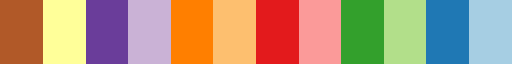

In [18]:
#Colour palette, max 10 categories to show
#from pypalettes import load_cmap, load_palette
#n = len(line_melted[group_name].unique())
n = 10
#cmap = load_cmap("Classic_Cyclic")
#palette = [to_hex(cmap(i / (n - 1))) for i in range(n)]
#palette

#OR use default
cmap = plt.get_cmap('Paired_r')
palette = [to_hex(cmap(i / (n - 1))) for i in range(n)]
print(palette)
cmap

#palette = ['#b15928', '#ffff99', '#6a3d9a', '#ff7f00', '#fdbf6f', '#e31a1c', '#33a02c', '#b2df8a', '#1f78b4', '#a6cee3']

In [ ]:
# Nested labels: Country only or provide own dictionary
from matplotlib.patches import FancyArrowPatch
from collections import defaultdict
countries = sorted(heatmap.index.tolist(),
                   key=lambda c: country2region.get(c, 'Unknown'))
heatmap = heatmap.loc[countries]

# rebuild continent_groups
continent_groups = {}
for i, country in enumerate(countries):
    cont = country2region.get(country, 'Unknown')
    continent_groups.setdefault(cont, []).append(i)

In [ ]:
def plot_heatmap(
    heatmap,
    line_melted,
    continent_dict,
    group_name,
    palette,
    prefix,
    group,
    threshold,
    axis_fontsize=7,
    title_fontsize=10,
    interval=2,
    figsize=(9, 4),
    plot_ratios=None,
    bracket_placement=-0.11,
    secondary_axis=False,
    save=False,
):
    if plot_ratios is None:
        plot_ratios = [0.3, len(heatmap) * 0.05]

    # sort countries by continent
    fig, axes = plt.subplots(
        nrows=2, ncols=1, figsize=figsize, sharex=True,
        gridspec_kw={'height_ratios': plot_ratios}
    )

    # manual gridlines 
    axes[0].set_facecolor("white")
    axes[0].grid(True, which="major", axis="y", color="lightgrey", linestyle="-", linewidth=0.5)
    axes[0].grid(True, which="major", axis="x", color="lightgrey", linestyle="-", linewidth=0.5)

    axes[1].set_facecolor("black")
    axes[1].grid(False)
    axes[1].xaxis.grid(False)
    axes[1].yaxis.grid(False)

    for i in range(1, len(heatmap.index)):
        axes[1].axhline(y=i, color='lightgrey', linewidth=0.5)

    # line plot 
    sns.lineplot(data=line_melted, linewidth=1, x='Date', y='Value',
                 hue=group_name, ax=axes[0], palette=palette)
    axes[0].set_ylabel("Rolling average (14-days)", fontsize=axis_fontsize)
    axes[0].tick_params(labelsize=axis_fontsize)
    axes[0].xaxis.set_major_locator(mdates.WeekdayLocator(interval=interval))
    axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
    axes[0].set_ylim(bottom=0)
    axes[0].legend(bbox_to_anchor=(1.01, 1), loc='upper left',
                   borderaxespad=0, fontsize=5)
    axes[0].axvspan(*mdates.datestr2num([str(mindate), str(mindate)]), color='red')

    # heatmap 
    xmin = mdates.date2num(pd.to_datetime(heatmap.columns[0]))
    xmax = mdates.date2num(pd.to_datetime(heatmap.columns[-1]))
    heatmap_plot = heatmap.copy().astype(float)
    heatmap_plot.replace([np.inf], 3, inplace=True)

    cmap = sns.color_palette("rocket", as_cmap=True)
    cmap.set_over('white')

    im = axes[1].imshow(
        heatmap_plot.values, aspect='auto', vmin=0, vmax=2,
        cmap=cmap, interpolation='none',
        extent=[xmin, xmax, len(heatmap), 0]
    )
    axes[1].xaxis_date()
    axes[1].set_facecolor("black")
    axes[1].tick_params(labelsize=axis_fontsize - 1)
    axes[1].tick_params(axis='x', labelrotation=90)
    axes[1].set_yticks([i + 0.5 for i in range(len(heatmap.index))])
    axes[1].set_yticklabels(heatmap.index, va='center')

    # colorbar 
    cbar_ax = fig.add_axes([0.88, 0.15, 0.02, 0.15])
    cbar = fig.colorbar(im, cax=cbar_ax)
    ticks = [0, 0.5, 1.0, 1.5, 2.0]    
    cbar.set_ticks(ticks)
    cbar.set_ticklabels([str(t) for t in ticks])
    cbar.ax.tick_params(labelsize=7)
    cbar.set_label('Mutation Ratio', fontsize=axis_fontsize)

    # inf box
    cbar_pos = cbar_ax.get_position()
    inf_ax = fig.add_axes([cbar_pos.x0, cbar_pos.y1 + 0.01, cbar_pos.width, cbar_pos.width])
    inf_ax.set_facecolor('white')
    inf_ax.set_xticks([])
    inf_ax.set_yticks([])
    inf_ax.text(0.5, 0.5, 'Inf', ha='center', va='center', color='black',
                fontsize=6, fontweight='bold', transform=inf_ax.transAxes)
    # nan box
    nan_ax = fig.add_axes([cbar_pos.x0, cbar_pos.y0 - cbar_pos.width - 0.01,
                           cbar_pos.width, cbar_pos.width])
    nan_ax.set_facecolor('black')
    nan_ax.set_xticks([])
    nan_ax.set_yticks([])
    nan_ax.text(0.5, 0.5, 'NaN', ha='center', va='center', color='white',
                fontsize=6, fontweight='bold', transform=nan_ax.transAxes)
    #  continent brackets
    if secondary_axis==True:
        # rebuild continent_groups
        #continent_groups = {}
        #for i, country in enumerate(countries):
        #    cont = continent_dict.get(country, 'Unknown')
        #    continent_groups.setdefault(cont, []).append(i)

        axes[1].set_yticks([i + 0.5 for i in range(len(heatmap.index))])
        axes[1].set_yticklabels(heatmap.index, va='center')

        ax2 = axes[1].twinx()
        ax2.set_ylim(axes[1].get_ylim())
        ax2.set_yticks([])

        text_placement = bracket_placement - 0.01
        for cont, rows in continent_groups.items():
            mid = (min(rows) + max(rows) + 1) / 2
            axes[1].text(text_placement, mid, cont,
                        transform=axes[1].get_yaxis_transform(),
                        va='center', ha='right', fontsize=axis_fontsize - 1)
            pad = 0.2
            axes[1].plot([bracket_placement, bracket_placement],
                        [min(rows) + pad, max(rows) + 1 - pad],
                        transform=axes[1].get_yaxis_transform(),
                        color='grey', linewidth=0.8, clip_on=False)
    else:
        pass
    #  final layout 
    plt.suptitle(f"{prefix} {group} {threshold}", size=title_fontsize)
    plt.subplots_adjust(left=0.4)
    plt.tight_layout()

    # reposition colorbar after tight_layout
    pos = axes[1].get_position()
    fig_height_inches = fig.get_size_inches()[1]
    max_cbar_height = 1 / fig_height_inches  # convert to figure fraction
    cbar_height = min(pos.height * 0.8, max_cbar_height)
    cbar_bottom = pos.y0 + (pos.height - cbar_height) / 2
    cbar_left = pos.x1 + 0.02
    
    cbar_ax.set_position([cbar_left, cbar_bottom, 0.02, cbar_height])

    cbar_pos = cbar_ax.get_position()
    inf_ax.set_position([cbar_pos.x0, cbar_pos.y1 + 0.01, cbar_pos.width, cbar_pos.width])
    nan_ax.set_position([cbar_pos.x0, cbar_pos.y0 - cbar_pos.width - 0.01, cbar_pos.width, cbar_pos.width])
    if save==True:
        plt.savefig('figures/' + prefix + "_" + group_name  + "_" + group + str(threshold)+ '.svg', dpi=600, bbox_inches='tight')
    else:
        pass
    return fig

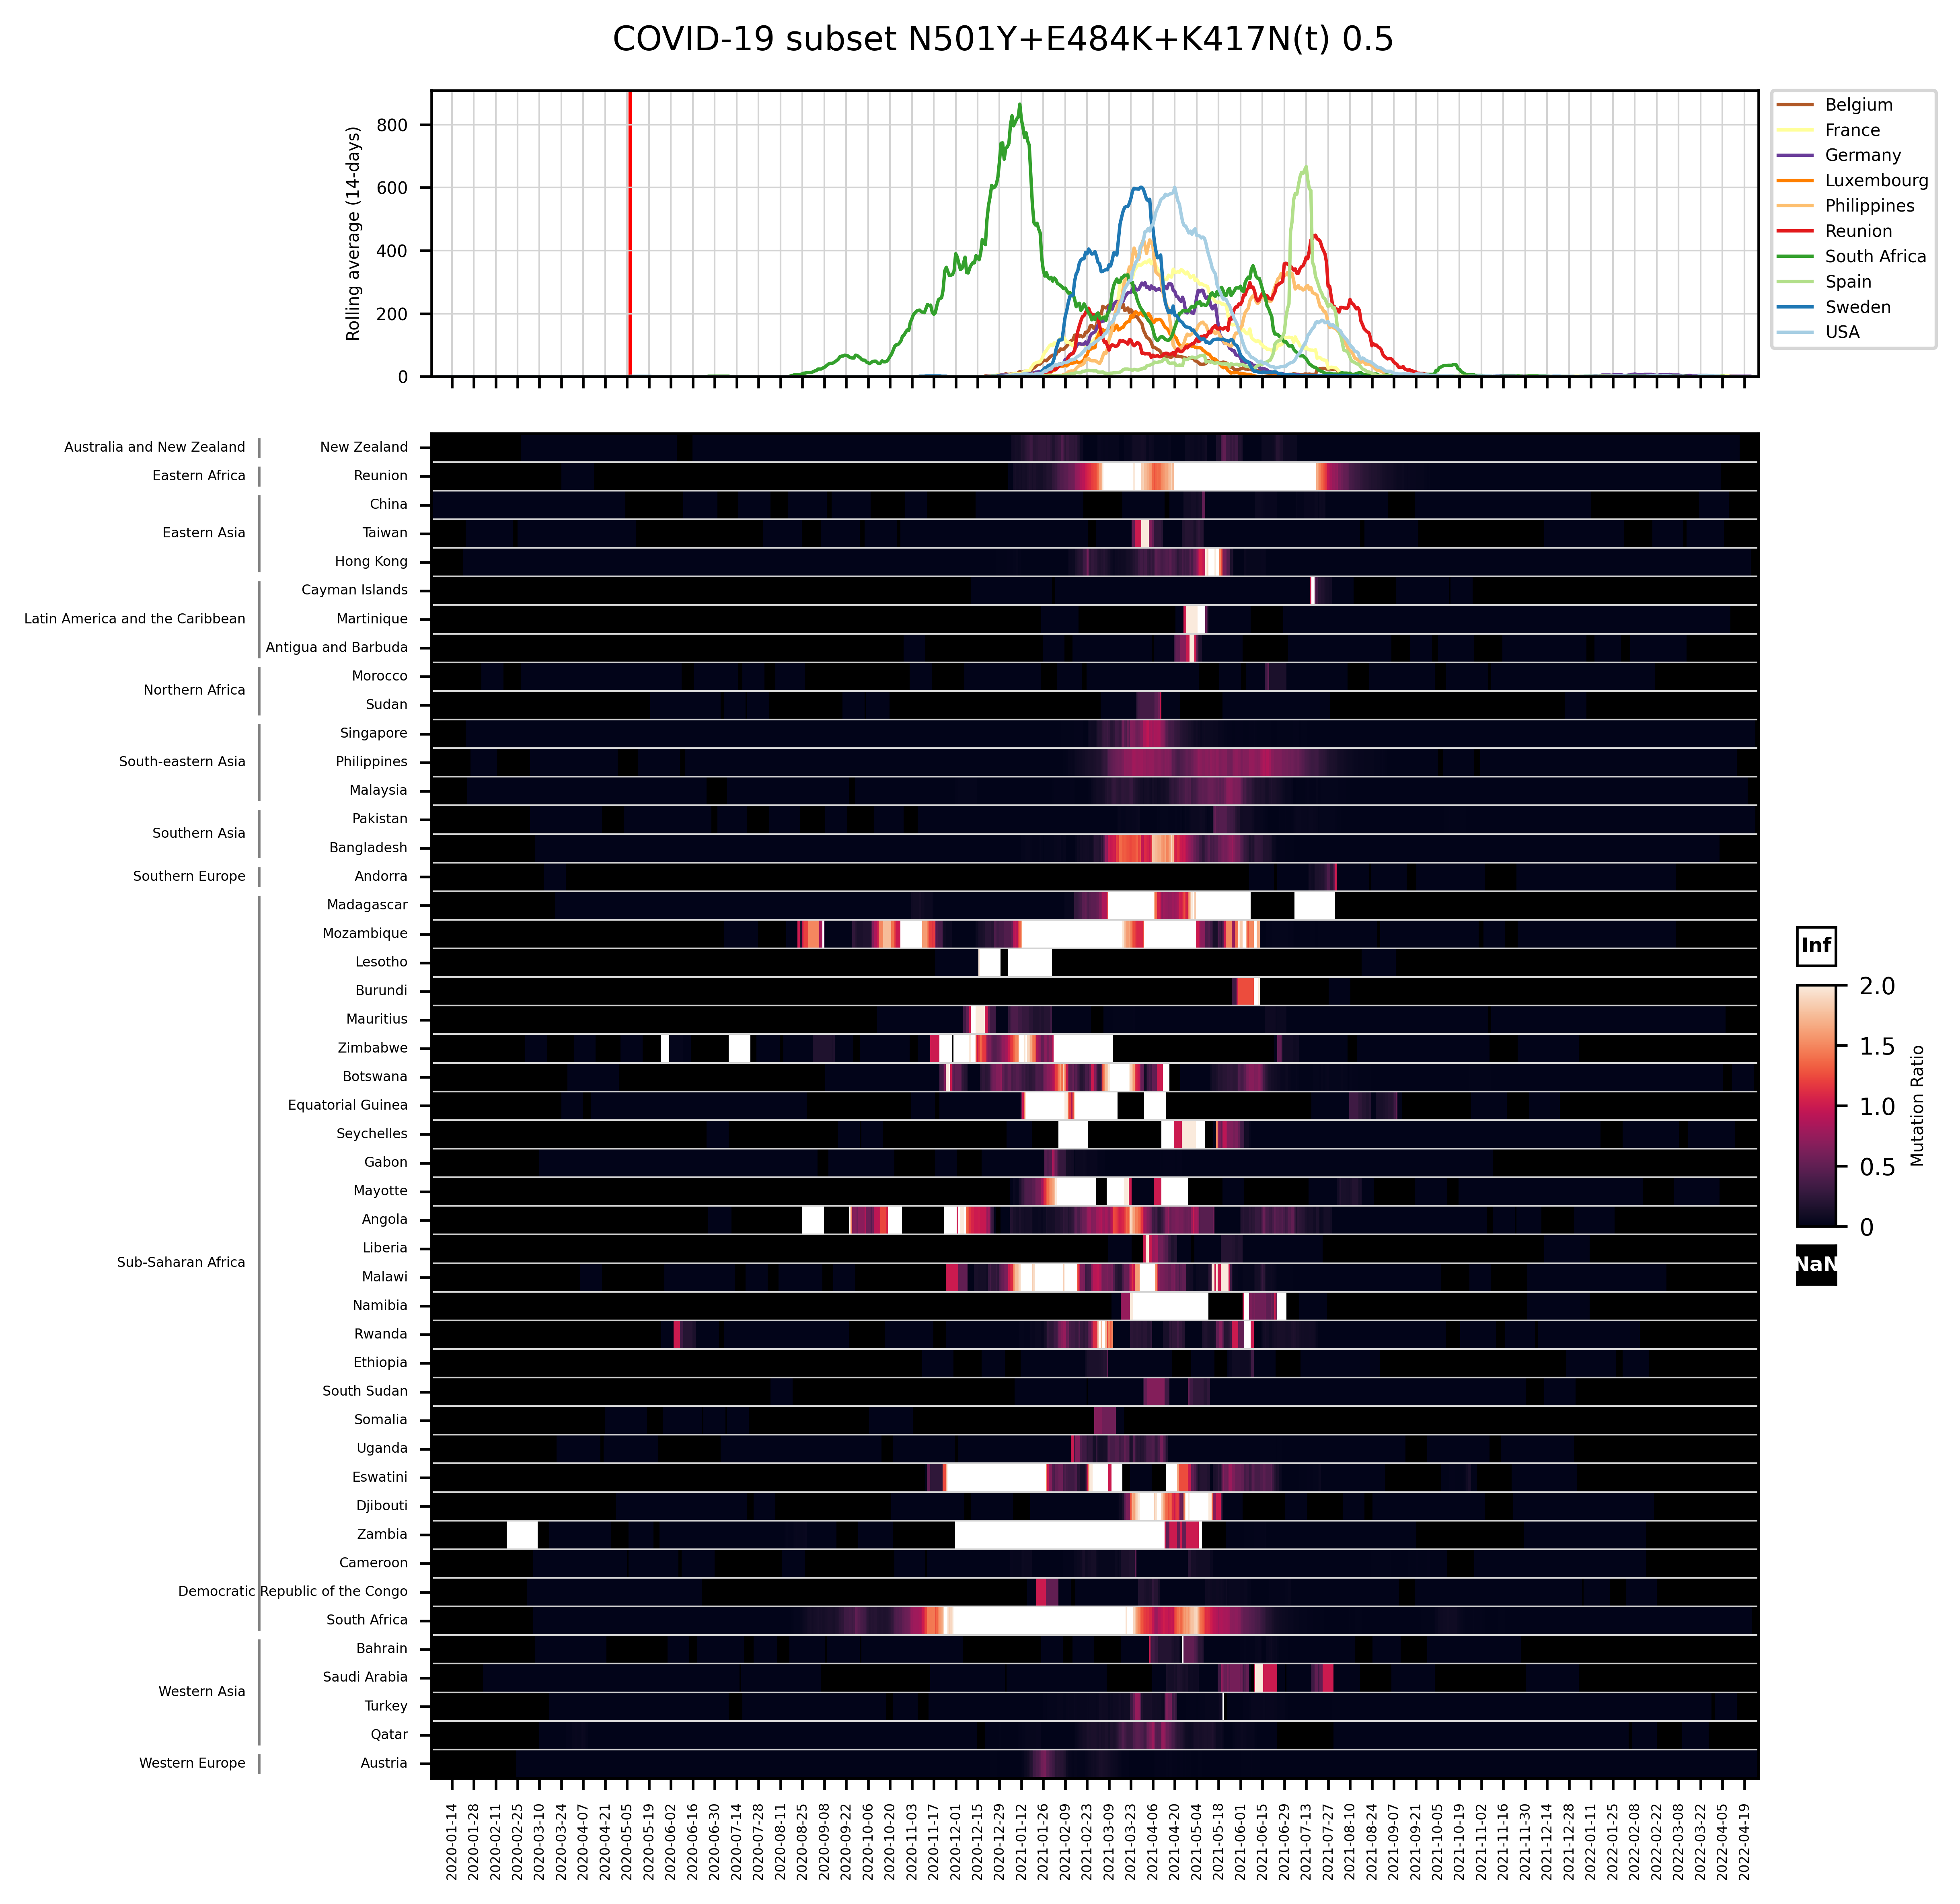

In [64]:
# Static plot
fig = plot_heatmap(
    heatmap=heatmap,
    line_melted=line_melted,
    continent_dict= continent_groups ,
    group_name=group_name,
    palette=palette,
    prefix=prefix,
    group=group,
    threshold=threshold,
    axis_fontsize=5,
    title_fontsize=10,
    interval=2,
    figsize=(8, 8),
    plot_ratios=[0.5, len(heatmap) * 0.05],
    bracket_placement=-0.13,
    secondary_axis=True, 
    save=False,
)
plt.show()

In [ ]:
def plot_heatmap_plotly(
    heatmap,
    line_melted,
    continent_dict,
    group_name,
    palette,
    prefix,
    group,
    threshold,
    mindate,
    fontsize=13,
    xticks_toshow=30,
    row_heights=None,
    bar_pos=3500,
    secondary_axis=False,
    bracket_size=0.3,
):
    if row_heights is None:
        row_heights = [0.5, 0.5]

    countries = heatmap.index.tolist()

    # figure 
    fig = make_subplots(
        rows=2, cols=1,
        shared_xaxes=True,
        row_heights=row_heights,
        vertical_spacing=0.05,
    )

    # line plot
    for i, grp in enumerate(line_melted[group_name].unique()):
        sub = line_melted[line_melted[group_name] == grp].sort_values('Date')
        fig.add_trace(
            go.Scatter(
                x=sub['Date'], y=sub['Value'],
                mode='lines',
                name=grp,
                line=dict(color=palette[i % len(palette)], width=2),
                legendgroup='lineplot',
                connectgaps=False,
                hovertemplate='%{y}<extra></extra>',
            ),
            row=1, col=1,
        )

    fig.add_vline(
        x=pd.Timestamp(mindate).timestamp() * 1000,
        line=dict(color='red', width=1),
        row=1, col=1,
    )
    fig.update_layout(hovermode="x unified")

    # heatmap
    heatmap_plot = heatmap.copy().astype(float)
    heatmap_plot.replace([np.inf], 3, inplace=True)
    heatmap_plot.replace([np.nan], -1, inplace=True)

    fig.add_trace(
        go.Heatmap(
            z=heatmap_plot.values,
            x=pd.to_datetime(heatmap.columns),
            y=countries,
            colorscale='Hot',
            zmin=0, zmax=2,
            colorbar=dict(
                title='',
                thickness=15,
                len=0.4,
                y=0.2,
                yanchor='middle',
            ),
            showscale=True,
            name='',
            hovertemplate='%{y}<br>%{x}<br>Ratio: %{z:.2f}<extra></extra>',
            hoverongaps=False,
        ),
        row=2, col=1,
    )

    # mutation ratio label
    fig.add_annotation(
        x=1.1, y=0.2,
        xref='paper', yref='paper',
        text='Mutation Ratio',
        showarrow=False,
        textangle=-90,
        xanchor='center',
        yanchor='middle',
        font=dict(size=fontsize),
    )

    # row separators
    for i in range(1, len(countries)):
        fig.add_hline(
            y=i - 0.5,
            line=dict(color='lightgrey', width=0.5),
            row=2, col=1,
        )

    # continent brackets
    if secondary_axis ==True:
        #continent_groups = {}
        #for i, country in enumerate(heatmap.index):
        #    cont = continent_dict.get(country, 'Unknown')
        #    continent_groups.setdefault(cont, []).append(i)

        max_country_len = max(len(c) for c in countries)
        left_margin = max_country_len * 7 + 200
        x_bracket = -(left_margin / bar_pos)
        x_text = x_bracket - 0.02

        for cont, rows in continent_dict.items():
            mid = (min(rows) + max(rows)) / 2
            top = min(rows) - bracket_size
            bot = max(rows) + bracket_size

            fig.add_annotation(
                x=x_text, y=mid,
                xref='paper', yref='y2',
                text=cont,
                showarrow=False,
                xanchor='right',
                font=dict(size=fontsize - 2),
            )
            fig.add_shape(
                type='line',
                x0=x_bracket, x1=x_bracket,
                y0=top, y1=bot,
                xref='paper', yref='y2',
                line=dict(color='grey', width=1),
            )

    # inf / nan annotations
    colorbar_x = 1.03
    colorbar_top = 0.40
    colorbar_bottom = 0.0

    fig.add_annotation(
        x=colorbar_x, y=colorbar_top + 0.03,
        xref='paper', yref='paper',
        text='<b>Inf</b>',
        showarrow=False,
        xanchor='left',
        font=dict(size=9, color='black'),
        bgcolor='white',
        bordercolor='black',
        borderwidth=1,
    )
    fig.add_annotation(
        x=colorbar_x, y=colorbar_bottom - 0.03,
        xref='paper', yref='paper',
        text='<b>NaN</b>',
        showarrow=False,
        xanchor='left',
        font=dict(size=9, color='white'),
        bgcolor='black',
        bordercolor='grey',
        borderwidth=1,
    )

    # layout
    fig.update_layout(
        height=1000,
        title=dict(
            text=f"{prefix} {group} {threshold}",
            x=0.5,
            xanchor='center',
            font=dict(size=14),
        ),
        plot_bgcolor='white',
        paper_bgcolor='white',
        margin=dict(l=left_margin, r=120),
        legend=dict(
            x=1.02, y=1,
            xanchor='left',
            font=dict(size=fontsize - 1),
        ),
        xaxis=dict(showgrid=True, gridcolor='lightgrey'),
        yaxis=dict(
            showgrid=True,
            gridcolor='lightgrey',
            title='Rolling average (14-days)',
        ),
        yaxis2=dict(showgrid=False),
        xaxis2=dict(tickangle=-90),
    )

    fig.update_yaxes(autorange='reversed', row=2, col=1)
    fig.update_xaxes(
        tickformat="%d %b %Y",
        nticks=xticks_toshow,
        tickfont=dict(size=fontsize - 1),
    )

    return fig




In [ ]:
#  plotly
fig = plot_heatmap_plotly(
    heatmap=heatmap,
    line_melted=line_melted,
    continent_dict=continent_groups,
    group_name=group_name,
    palette=palette,
    prefix=prefix,
    group=group,
    threshold=threshold,
    mindate=mindate,
    fontsize=13,
    xticks_toshow=30,
    row_heights=[0.3, 0.7],
    height=1000, # plot height (increase if all groups are not showing)
    secondary_axis=True,
    bar_pos=2500, #secondary bar pos
)
fig.show()

In [ ]:
fig.write_html(path + "file.html")